# **Milestone 3: Integrated Notebook of U.S. Childcare Cost Analysis**

A1 Team6:
*   Yuanhao Li
*   Xinying Wang
*   Zexuan Wang
*   Junqi Fang







##  Project Motivation and Executive Summary:

In Milestone 3, our goal is to integrate M2 individual analyses into a cohesive, reproducible workflow. We conduct unified data preparation and feature framework so that results can be directly compared and meaningfully integrated. We treat the 2018 cross-sectional clustering as a structural backbone, then examine how income-adjusted outliers (Q2) relate to cluster membership, whether trajectory types (Q3) concentrate in specific burden groups, and whether these patterns are primarily state-driven or cross-state (Q4).

Through this integration, we aim to determine whether our different analytical views are capturing the same underlying structure or whether they reveal complementary or even conflicting patterns. Any inconsistencies, redundancies, or methodological tensions uncovered during this process will be explicitly documented and reflected upon in later sections.

## 1.Data Loading & Preprocessing

In the cells below, we load and merge our datasets. We then run data quality checks for missingness, duplicates and coverage. We also create two aligned analysis samples for M3: 2018 cross-section and balanced panel subset for trajectory work.

In [99]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
CHILDCARE_FILE = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/childcare_costs.csv"
COUNTY_REF_FILE = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/counties.csv"

df = pd.read_csv(CHILDCARE_FILE)
ref = pd.read_csv(COUNTY_REF_FILE)

SEED = 820
np.random.seed(SEED)

print("childcare shape:", df.shape)
print("counties shape:", ref.shape)

df["county_fips_code"] = df["county_fips_code"].astype(str).str.zfill(5)
df["study_year"] = pd.to_numeric(df["study_year"], errors="coerce")
ref["county_fips_code"] = ref["county_fips_code"].astype(str).str.zfill(5)

df = df.merge(ref[["county_fips_code", "county_name", "state_name", "state_abbreviation"]].drop_duplicates(), on="county_fips_code", how="left")

df.head(3)

childcare shape: (34567, 61)
counties shape: (3144, 4)


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,01001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,01001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,01001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL


In [101]:
# Check missing values and coverage
key_cost_cols = ["mc_infant", "mc_toddler", "mc_preschool"]
key_context_cols = ["mhi_2018", "unr_20to64", "flfpr_20to64"]

cols_to_check = [c for c in (key_cost_cols + key_context_cols) if c in df.columns]

miss = df[cols_to_check].isna().mean().sort_values(ascending=False)
miss_df = pd.DataFrame({"missing_rate": miss, "missing_pct": (miss * 100).round(1)})
miss_df

,missing_rate,missing_pct
mc_infant,0.31747,31.7
mc_toddler,0.31747,31.7
mc_preschool,0.31747,31.7
mhi_2018,0.00000,0.0
unr_20to64,0.00000,0.0
flfpr_20to64,0.00000,0.0


We create analysis samples for following analysis: 2018 cross-section and panel subset for trajectories.

In [102]:
df_xsec_2018 = df[df["study_year"] == 2018].copy()
print("df_xsec_2018:", df_xsec_2018.shape)

# keep counties with at least min_years non-missing mc_infant
MIN_YEARS = 8
panel_counts = (df.dropna(subset=["mc_infant"]).groupby("county_fips_code")["study_year"].nunique())

eligible_fips = panel_counts[panel_counts >= MIN_YEARS].index
df_panel = df[df["county_fips_code"].isin(eligible_fips)].copy()

print("df_panel:", df_panel.shape)
print("eligible counties:", len(eligible_fips))

df_xsec_2018: (3142, 64)
df_panel: (21857, 64)
eligible counties: 1987


## 2.Feature Construction

In the cells below, we build a shared feature set:
- cost level: mc_infant, mc_toddler, mc_preschool
- burden: log(cost) - log(income)
- socioeconomic context variables

In [103]:
df_2018 = df_xsec_2018.copy()

# Log transforms
df_2018["log_mhi"] = np.log(df_2018["mhi_2018"].where(df_2018["mhi_2018"] > 0))
df_2018["log_infant"] = np.log(df_2018["mc_infant"].where(df_2018["mc_infant"] > 0))
df_2018["log_toddler"] = np.log(df_2018["mc_toddler"].where(df_2018["mc_toddler"] > 0))
df_2018["log_preschool"] = np.log(df_2018["mc_preschool"].where(df_2018["mc_preschool"] > 0))

# Burden proxies
df_2018["burden_infant"] = df_2018["log_infant"] - df_2018["log_mhi"]
df_2018["burden_toddler"] = df_2018["log_toddler"] - df_2018["log_mhi"]
df_2018["burden_preschool"] = df_2018["log_preschool"] - df_2018["log_mhi"]

# Final feature list
feature_cols = ["log_infant", "log_toddler", "log_preschool","burden_infant", "burden_toddler",
          "burden_preschool", "unr_20to64", "flfpr_20to64", "h_under6_both_work", "emp_service", "emp_sales"]

feature_cols = [c for c in feature_cols if c in df_2018.columns]

df_2018_model = df_2018.dropna(subset=feature_cols).copy()
X_2018 = df_2018_model[feature_cols]

print("Model sample size (2018):", df_2018_model.shape[0])
print("Features used:", feature_cols)
X_2018.head()

Model sample size (2018): 2360
Features used: ['log_infant', 'log_toddler', 'log_preschool', 'burden_infant', 'burden_toddler', 'burden_preschool', 'unr_20to64', 'flfpr_20to64', 'h_under6_both_work', 'emp_service', 'emp_sales']


,log_infant,log_toddler,log_preschool,burden_infant,burden_toddler,burden_preschool,unr_20to64,flfpr_20to64,h_under6_both_work,emp_service,emp_sales
10,4.790903,4.790903,4.620059,-6.190756,-6.190756,-6.361600,3.9,66.2,1261,15.94,22.10
21,4.790903,4.790903,4.711600,-6.141526,-6.141526,-6.220828,4.1,70.1,6007,18.11,24.10
32,4.456670,4.456670,4.403666,-5.982901,-5.982901,-6.035906,9.6,60.8,355,14.64,19.83
43,4.652340,4.652340,4.620059,-6.069605,-6.069605,-6.101886,7.2,59.5,556,18.72,18.90
54,5.182233,5.182233,5.067897,-5.611099,-5.611099,-5.725434,3.7,56.3,1400,13.00,21.40


## 3.Integrated Backbone Analysis

In this notebook, we use a single integrated backbone analysis. We start with a 2018 cross-section and run distance-based clustering after standardization. We first use hierarchical clustering to quickly inspect whether the data naturally separates into a small number of groups, which helps us avoid choosing an arbitrary k. We then run KMeans for a small range of k values and compare inertia and silhouette to select a reasonable k that balances stability and interpretability.

The goal of this section is to establish an interpretable county grouping that we can reuse later when integrating following analysis.

In [104]:
features_base = ["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]

df_clu = df_xsec_2018[features_base].dropna().copy()
df_clu.head()

,mc_infant,mc_toddler,mc_preschool,mhi_2018
10,120.41,120.41,101.50,58786.0
21,120.41,120.41,111.23,55962.0
32,86.20,86.20,81.75,34186.0
43,104.83,104.83,101.50,45340.0
54,178.08,178.08,158.84,48695.0


In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_clu)

print("X shape:", X.shape)

X shape: (2360, 4)


### 1)Hierarchical Clustering

We use hierarchical clustering as a quick structure check. The dendrogram helps us see whether there is a large “merge jump”, which usually suggests that k should not be too small. This step is mainly diagnostic and supports our k-selection reasoning for KMeans.


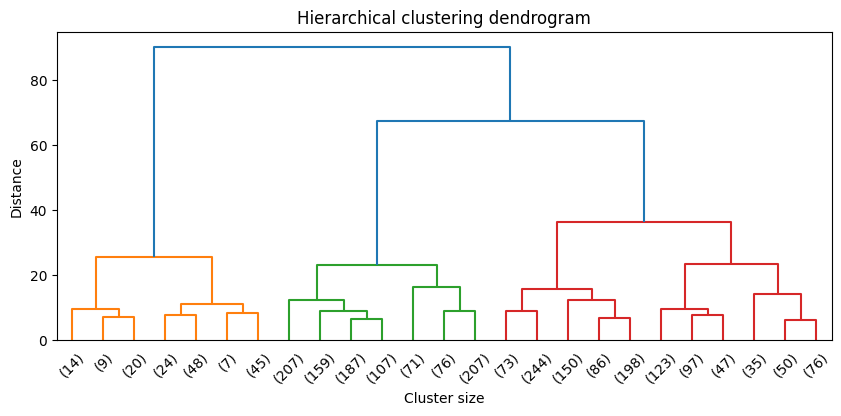

In [106]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=25)
plt.title("Hierarchical clustering dendrogram")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

### 2)KMeans clustering

To choose a reasonable k, we compare a small range of k values using two simple diagnostics: inertia and silhouette score. The former one is used as a rough elbow signal, and the latter one helps evaluate separation.


In [107]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inertias = []
silhs = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X, labels))

pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhs})

,k,inertia,silhouette
0,2,4470.788657,0.548621
1,3,2946.652921,0.408959
2,4,2253.440420,0.376352
3,5,1980.390312,0.359317
4,6,1717.182905,0.353400
5,7,1464.941714,0.324395
6,8,1275.824309,0.355072


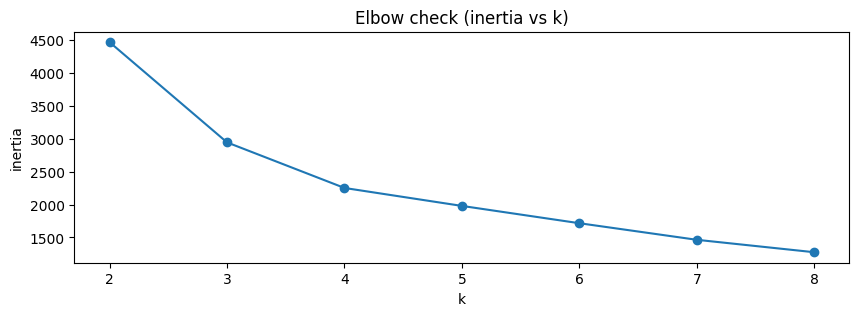

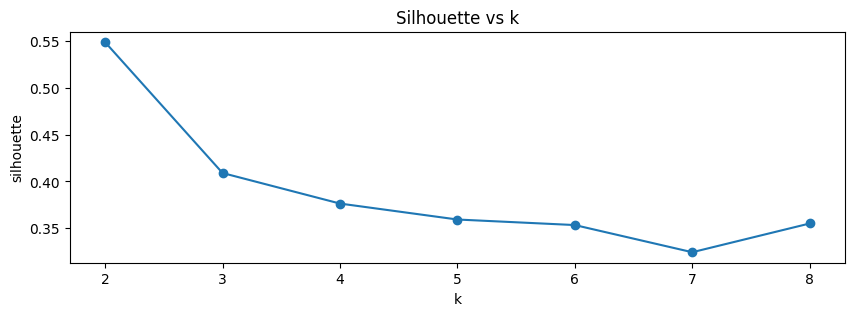

In [108]:
plt.figure(figsize=(10, 3))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow check (inertia vs k)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(list(ks), silhs, marker="o")
plt.title("Silhouette vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()

Based on the hierarchical structure check and the k diagnostics above, we select a small k that produces stable and interpretable clusters. We start with k=3, which is consistent with our M2 Q1 exploration, and compare k=4 as a sensitivity check.


In [109]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=SEED, n_init=10)
labels = kmeans.fit_predict(X)

df_backbone = df_clu.copy()
df_backbone["cluster"] = labels

df_backbone["cluster"].value_counts().sort_index()

,count
cluster,
0,1128
1,202
2,1030


In [110]:
k_alt = 4
kmeans4 = KMeans(n_clusters=k_alt, random_state=SEED, n_init=10)
labels4 = kmeans4.fit_predict(X)

df_backbone4 = df_clu.copy()
df_backbone4["cluster"] = labels4

print("k=3 sizes:\n", df_backbone["cluster"].value_counts().sort_index())
print("\nk=4 sizes:\n", df_backbone4["cluster"].value_counts().sort_index())

df_backbone4.groupby("cluster")[features_base].mean()

k=3 sizes:
 cluster
0    1128
1     202
2    1030
Name: count, dtype: int64

k=4 sizes:
 cluster
0    929
1    118
2    376
3    937
Name: count, dtype: int64


,mc_infant,mc_toddler,mc_preschool,mhi_2018
cluster,,,,
0,163.045974,146.890258,136.543617,53022.258342
1,328.508814,283.303814,257.123305,83071.915254
2,223.790532,195.014867,182.159468,63786.949468
3,116.186030,108.052252,101.485582,42809.289221


In [111]:
# Cluster profiles
profile = df_backbone.groupby("cluster")[features_base].agg(["mean", "median", "count"])
profile

mc_infant                mc_toddler               mc_preschool  \
               mean  median count        mean  median count         mean   
cluster                                                                    
0        121.401569  124.75  1128  112.413254  116.00  1128   105.056835   
1        299.094356  285.00   202  256.517228  251.78   202   233.929356   
2        180.473078  175.00  1030  161.012447  156.25  1030   150.500660   

                            mhi_2018                 
          median count          mean   median count  
cluster                                              
0        105.625  1128  43774.190603  43151.5  1128  
1        225.000   202  78548.391089  77423.0   202  
2        147.630  1030  56225.533010  54551.0  1030

### 3)PCA


To visually assess whether the clusters occupy distinct regions in feature space, we project the standardized features onto the first two principal components.

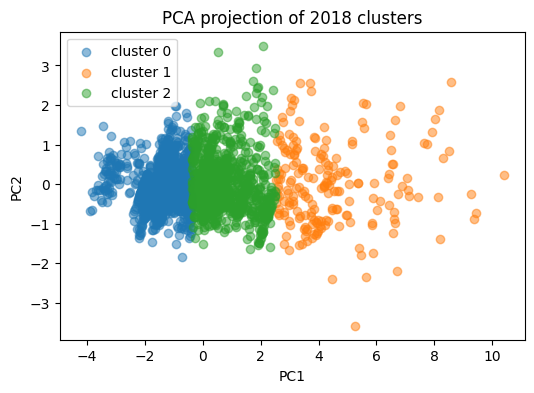

Explained variance ratio: [0.86813612 0.11243531]


In [112]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 4))
for c in sorted(df_backbone["cluster"].unique()):
    idx = df_backbone["cluster"] == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], alpha=0.5, label=f"cluster {c}")

plt.title("PCA projection of 2018 clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

### 4)Income vs Childcare Costs

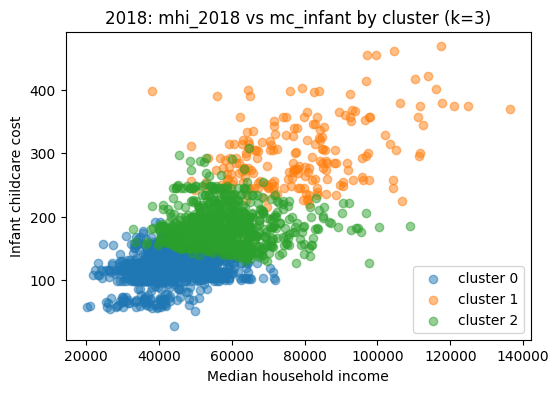

In [113]:
plt.figure(figsize=(6, 4))
for c in sorted(df_backbone["cluster"].unique()):
    tmp = df_backbone[df_backbone["cluster"] == c]
    plt.scatter(tmp["mhi_2018"], tmp["mc_infant"], alpha=0.5, label=f"cluster {c}")

plt.title("2018: mhi_2018 vs mc_infant by cluster (k=3)")
plt.xlabel("Median household income")
plt.ylabel("Infant childcare cost")
plt.legend()
plt.show()

To make the backbone clusters more interpretable for Milestone 3 integration, we summarize each cluster using simple medians and a burden proxy. We compute a proxy affordability measure as log infant cost minus log income, which helps distinguish high cost areas from high burden areas.

In [167]:
cluster_summary = (df_backbone.groupby("cluster")[["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]].median())

cluster_summary["burden_proxy_infant"] = np.log(cluster_summary["mc_infant"]) - np.log(cluster_summary["mhi_2018"])
cluster_summary["burden_proxy_toddler"] = np.log(cluster_summary["mc_toddler"]) - np.log(cluster_summary["mhi_2018"])
cluster_summary["burden_proxy_preschool"] = np.log(cluster_summary["mc_preschool"]) - np.log(cluster_summary["mhi_2018"])

cluster_summary

,mc_infant,mc_toddler,mc_preschool,mhi_2018,burden_proxy_infant,burden_proxy_toddler,burden_proxy_preschool
cluster,,,,,,,
0,124.75,116.00,105.625,43151.5,-5.846161,-5.918882,-6.012577
1,285.00,251.78,225.000,77423.0,-5.604550,-5.728483,-5.840939
2,175.00,156.25,147.630,54551.0,-5.742105,-5.855434,-5.912182


Cluster 1 has the highest median infant toddler and preschool costs, but it also has the highest median household income. In contrast, cluster 0 has much lower childcare costs and lower income levels. Cluster 2 lies between these groups in terms of cost and income, but its burden proxy values suggest relatively higher affordability pressure compared to cluster 0.

To connect the clusters to the core affordability story, we plot income versus infant cost and highlight the cluster median point. This gives an intuitive view of how clusters differ in cost level and income context.


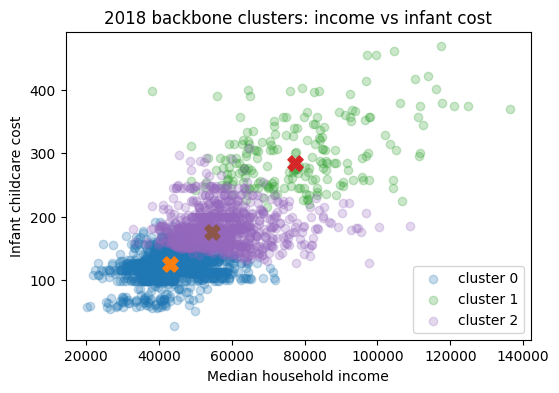

In [170]:
plt.figure(figsize=(6, 4))

for c in sorted(df_backbone["cluster"].unique()):
    d = df_backbone[df_backbone["cluster"] == c]
    plt.scatter(d["mhi_2018"], d["mc_infant"], alpha=0.25, label=f"cluster {c}")

    # mark median point
    med_x = d["mhi_2018"].median()
    med_y = d["mc_infant"].median()
    plt.scatter([med_x], [med_y], marker="X", s=120)

plt.title("2018 backbone clusters: income vs infant cost")
plt.xlabel("Median household income")
plt.ylabel("Infant childcare cost")
plt.legend()
plt.show()

From the analysis above, we found that counties in 2018 could be grouped into a small number of distinct childcare cost-income structures. Using standardized cost variables and median household income, k=3 produced stable and interpretable clusters. Broadly, the groups reflected differences in cost levels and income context rather than random variation, suggesting that counties do follow structured affordability patterns rather than forming a continuous gradient.

In Milestone 3, we treat this clustering as a structural backbone for integration. We focus on whether this grouping remains meaningful when connected to income-adjusted outliers (Q2), trajectory types (Q3), and state-level structure (Q4). This backbone provides a common reference point across analyses, allowing us to test whether different methods are capturing the same underlying structure or revealing complementary dimensions of childcare burden.

Overall, the integrated backbone analysis confirms that there is a coherent cross-sectional structure in 2018, which can now be used to evaluate persistence, deviation, and spatial concentration in a more systematic way.

## 4.Income-adjusted Outlier Integration

In M2, we examined counties that appear unusually expensive given their income level, focusing on deviations from the typical cost-income relationship. In M3, we integrate this outlier view with our backbone clusters from Section 3.

We first fit a simple income-adjusted baseline model and compute residuals. Counties with large positive residuals are interpreted as higher cost than expected given income. We then connect these residual outliers to the backbone clusters to see whether outliers concentrate in particular groups or appear broadly across clusters.

Finally, as an explicit integration attempt, we add the residual signal as an additional feature and re-run clustering as a small sensitivity check. The goal is not to optimize clustering, but to test whether the outlier perspective materially changes the cluster structure or mainly refines interpretation within clusters.


### 1)merge cluster labels back to county info.

In [114]:
features_base = ["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]

df_work = df_xsec_2018[["county_fips_code", "county_name", "state_name", "state_abbreviation"] + features_base].copy()
df_work = df_work.dropna(subset=features_base)

df_work = df_work.loc[df_backbone.index].copy()
df_work["cluster"] = df_backbone["cluster"].values

print("df_work shape:", df_work.shape)
df_work.head(3)

df_work shape: (2360, 9)


,county_fips_code,county_name,state_name,state_abbreviation,mc_infant,mc_toddler,mc_preschool,mhi_2018,cluster
10,01001,Autauga County,Alabama,AL,120.41,120.41,101.50,58786.0,0
21,01003,Baldwin County,Alabama,AL,120.41,120.41,111.23,55962.0,0
32,01005,Barbour County,Alabama,AL,86.20,86.20,81.75,34186.0,0


### 2)Fit a simple income-adjusted baseline and residuals.

In [146]:
from sklearn.linear_model import LinearRegression

df_work["log_mhi"] = np.log(df_work["mhi_2018"].where(df_work["mhi_2018"] > 0))
df_work["log_infant"] = np.log(df_work["mc_infant"].where(df_work["mc_infant"] > 0))

tmp = df_work.dropna(subset=["log_mhi", "log_infant"]).copy()

X_income = tmp[["log_mhi"]].values
y_cost = tmp["log_infant"].values

lr = LinearRegression()
lr.fit(X_income, y_cost)

tmp["pred_log_infant"] = lr.predict(X_income)
tmp["resid_log_infant"] = tmp["log_infant"] - tmp["pred_log_infant"]

print("Baseline model: log(mc_infant) ~ log(mhi_2018)")
print("slope:", lr.coef_[0], "intercept:", lr.intercept_)
tmp[["county_name", "state_abbreviation", "log_mhi", "log_infant", "pred_log_infant", "resid_log_infant", "cluster"]].head(3)

Baseline model: log(mc_infant) ~ log(mhi_2018)
slope: 0.8554373403938331 intercept: -4.230940661689492


,county_name,state_abbreviation,log_mhi,log_infant,pred_log_infant,resid_log_infant,cluster
10,Autauga County,AL,10.981659,4.790903,5.163181,-0.372278,0
21,Baldwin County,AL,10.932428,4.790903,5.121067,-0.330164,0
32,Barbour County,AL,10.439571,4.456670,4.699459,-0.242788,0


Visual check: income vs cost

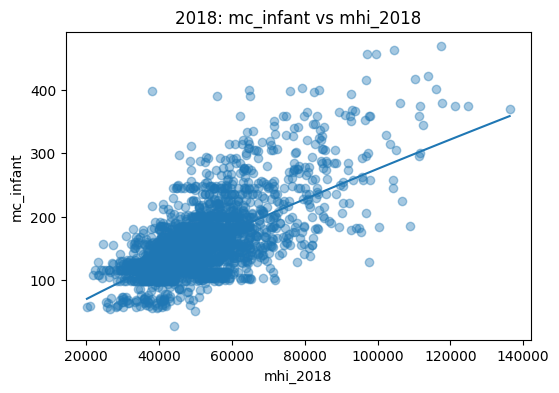

In [116]:
plt.figure(figsize=(6,4))
plt.scatter(tmp["mhi_2018"], tmp["mc_infant"], alpha=0.4)

x_line = np.linspace(tmp["log_mhi"].min(), tmp["log_mhi"].max(), 100)
y_line = lr.intercept_ + lr.coef_[0] * x_line

plt.plot(np.exp(x_line), np.exp(y_line))
plt.title("2018: mc_infant vs mhi_2018")
plt.xlabel("mhi_2018")
plt.ylabel("mc_infant")
plt.show()

In [117]:
# Standardize residuals
tmp["resid_z"] = (tmp["resid_log_infant"] - tmp["resid_log_infant"].mean()) / tmp["resid_log_infant"].std()

# Define outliers
q = 0.95
thr = tmp["resid_log_infant"].quantile(q)
tmp["outlier_high_cost_given_income"] = (tmp["resid_log_infant"] >= thr).astype(int)

print("Outlier threshold (top 5% residual):", thr)
tmp["outlier_high_cost_given_income"].value_counts()

Outlier threshold (top 5% residual): 0.3987291148527808


,count
outlier_high_cost_given_income,
0,2242
1,118


In [118]:
# Show top 15 highest-residual counties
top_outliers = (
    tmp.sort_values("resid_log_infant", ascending=False)
       .loc[:, ["county_name", "state_abbreviation", "mc_infant", "mhi_2018", "resid_log_infant", "resid_z", "cluster"]]
       .head(15)
)
top_outliers

,county_name,state_abbreviation,mc_infant,mhi_2018,resid_log_infant,resid_z,cluster
20139,Bronx County,NY,397.70,38085.0,1.193848,4.698150,1
20370,Kings County,NY,390.82,56015.0,0.846371,3.330722,1
2176,Humboldt County,CA,297.69,45528.0,0.751502,2.957383,2
13528,Suffolk County,MA,400.00,64582.0,0.747846,2.942996,1
33972,Milwaukee County,WI,312.00,48742.0,0.740100,2.912513,1
20557,Queens County,NY,390.15,64987.0,0.717564,2.823831,1
15134,Ramsey County,MN,358.00,62304.0,0.667633,2.627335,1
2088,Butte County,CA,287.77,48443.0,0.664522,2.615092,2
25507,Allendale County,SC,156.25,24560.0,0.634889,2.498479,0
2154,Fresno County,CA,287.20,51261.0,0.614171,2.416945,2


### 3)Outlier concentration by cluster

To explicitly integrate Q2 with backbone clustering, we examine whether income-adjusted outliers are concentrated in specific clusters. If outliers mostly appear in one cluster, it suggests the backbone groups already capture much of the “high-burden” structure. If outliers are spread across clusters, it suggests the residual view provides additional information beyond the baseline grouping.


In [119]:
# Outlier rate by cluster
cluster_outlier = (
    tmp.groupby("cluster")["outlier_high_cost_given_income"]
       .agg(["mean", "sum", "count"])
       .rename(columns={"mean": "outlier_rate", "sum": "n_outliers", "count": "n_total"})
)

cluster_outlier["outlier_rate"] = (cluster_outlier["outlier_rate"] * 100).round(2)
cluster_outlier

,outlier_rate,n_outliers,n_total
cluster,,,
0,1.15,13,1128
1,30.20,61,202
2,4.27,44,1030


In [120]:
pd.crosstab(tmp["cluster"], tmp["outlier_high_cost_given_income"], rownames=["cluster"], colnames=["outlier"])

outlier,0,1
cluster,,
0,1115,13
1,141,61
2,986,44


Scatter colored by cluster and mark outliers

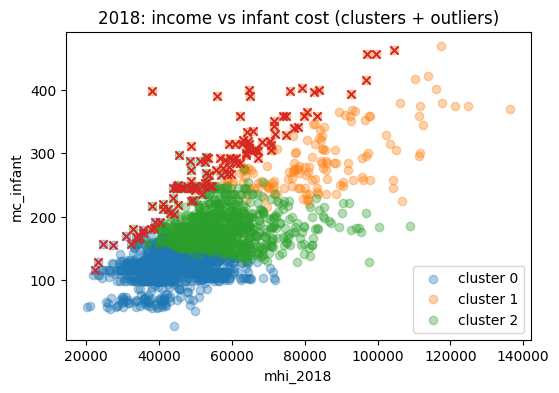

In [121]:
plt.figure(figsize=(6,4))

for c in sorted(tmp["cluster"].unique()):
    d = tmp[tmp["cluster"] == c]
    plt.scatter(d["mhi_2018"], d["mc_infant"], alpha=0.35, label=f"cluster {c}")

out = tmp[tmp["outlier_high_cost_given_income"] == 1]
plt.scatter(out["mhi_2018"], out["mc_infant"], marker="x")

plt.title("2018: income vs infant cost (clusters + outliers)")
plt.xlabel("mhi_2018")
plt.ylabel("mc_infant")
plt.legend()
plt.show()

### 4)Add residual feature and re-run clustering

As a direct technical integration attempt, we add the income-adjusted residual signal into the feature space and re-run KMeans. This helps us test whether the “outlier perspective” materially reshapes the clustering structure or mainly provides an interpretive layer on top of the existing backbone clusters.


In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Build aligned residual vector
resid_aligned = tmp["resid_log_infant"].reindex(df_backbone.index)
mask = resid_aligned.notna()

X_base = X[mask.values]
resid_vec = resid_aligned[mask].values.reshape(-1, 1)

# Add residual feature then scale again
X_aug = np.hstack([X_base, resid_vec])
X_aug = StandardScaler().fit_transform(X_aug)

k_final = 3
km_aug = KMeans(n_clusters=k_final, random_state=SEED, n_init=10)
labels_aug = km_aug.fit_predict(X_aug)

print("Augmented clustering done. n rows:", X_aug.shape[0])
pd.Series(labels_aug).value_counts().sort_index()

Augmented clustering done. n rows: 2360


,count
0,1054
1,1028
2,278


Compare old vs new clusters

In [123]:
# Compare cluster assignments
old_labels = df_backbone.loc[mask, "cluster"].values
new_labels = labels_aug

pd.crosstab(old_labels, new_labels, rownames=["old_cluster"], colnames=["new_cluster"])

new_cluster,0,1,2
old_cluster,,,
0,1004,124,0
1,0,0,202
2,50,904,76


Examine the full residual distribution within each cluster. This helps us distinguish two cases: one is that a cluster is systematically high residual, meaning many counties are higher cost than expected given income; the other case is that only a small number of counties are extreme outliers while the rest of the cluster follows the baseline relationship.

<Figure size 600x400 with 0 Axes>

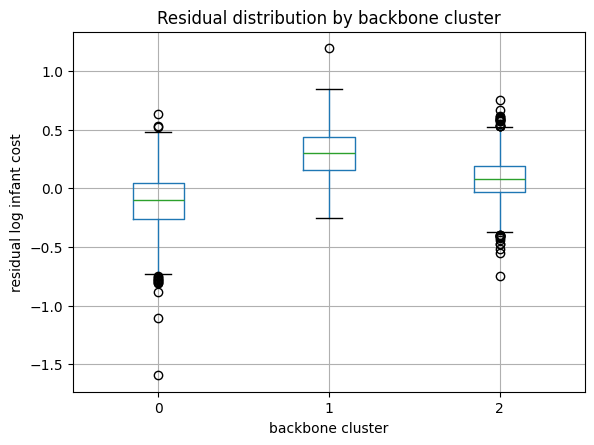

In [171]:
# Boxplot of residuals by backbone cluster
plt.figure(figsize=(6,4))
tmp.boxplot(column="resid_log_infant", by="cluster")
plt.title("Residual distribution by backbone cluster")
plt.suptitle("")
plt.xlabel("backbone cluster")
plt.ylabel("residual log infant cost")
plt.show()

The residual distributions differ noticeably across backbone clusters. Cluster 1 has a clearly positive median residual and a distribution that is shifted upward relative to the other clusters. This suggests that many counties in cluster 1 have higher infant childcare costs than expected given their income level, not just a few extreme outliers. In contrast, cluster 0 has a negative median residual and a wider lower tail, indicating that counties in this group tend to have lower costs relative to income. Cluster 2 lies between these two groups, with a median residual close to zero but a moderate spread on both sides.

In M2 analysis, we identified counties that appeared unusually expensive relative to their income level by examining residuals from a baseline cost-income relationship. A small group of counties showed consistently high positive residuals, suggesting that income alone does not fully explain variation in childcare costs.

In Milestone 3, we explicitly integrated this residual-based view with our backbone clusters from Section 3. When we compared the original clustering with the residual-augmented clustering, most counties remained in the same group. For example, the majority of old cluster 1 counties mapped cleanly into a single new cluster, and a large share of old cluster 2 counties also remained together. Only one group showed partial reshuffling. This suggests that the backbone clustering already captures much of the income-driven structure, and that the residual signal mainly refines interpretation rather than fundamentally reshaping the grouping.

Overall, this integration confirms that the cross-sectional clusters are structurally stable, while the income-adjusted residual perspective helps us identify counties that are unusually expensive within each group.

## 5.Trajectory Type Analysis

In M2, we tried to cluster county trajectories directly with K-means, but the separation was not visually clear. For M3, we adjust our approach. Instead of forcing K-means on high-dimensional yearly vectors, we summarize each county's 2008-2018 trajectory into a small set of interpretable features using a panel subset with sufficient coverage. We then use hierarchical clustering on these features to form a few trajectory types.

Finally, we integrate these trajectory types with our 2018 backbone clusters to see whether certain burden groups are more likely to experience fast worsening, high volatility, or stable patterns over time.


### 1)Build a trajectory metric

In [124]:
panel = df_panel.copy()

panel["log_mhi"] = np.log(panel["mhi_2018"].where(panel["mhi_2018"] > 0))
panel["log_infant"] = np.log(panel["mc_infant"].where(panel["mc_infant"] > 0))

# burden proxy
panel["burden_infant"] = panel["log_infant"] - panel["log_mhi"]

# keep years of interest
panel = panel[(panel["study_year"] >= 2008) & (panel["study_year"] <= 2018)].copy()

# keep rows with burden available
panel = panel.dropna(subset=["burden_infant", "study_year", "county_fips_code"])

print("panel rows (burden available):", panel.shape)
panel[["county_fips_code", "study_year", "burden_infant"]].head()

panel rows (burden available): (20966, 67)


,county_fips_code,study_year,burden_infant
0,01001,2008,-6.322658
1,01001,2009,-6.350615
2,01001,2010,-6.374644
3,01001,2011,-6.349959
4,01001,2012,-6.328084


### 2)Create trajectory features per county

In [148]:
years_full = list(range(2008, 2019))
mat = panel.pivot_table(index="county_fips_code", columns="study_year", values="burden_infant", aggfunc="mean")

# require at least 8 non-missing years
keep = mat.notna().sum(axis=1) >= 8
mat = mat.loc[keep].copy()
year_vals = np.array(mat.columns, dtype=float)

# compute features
traj_features = []
for fips, row in mat.iterrows():
    y = row.values.astype(float)
    mask = ~np.isnan(y)

    x = year_vals[mask]
    yy = y[mask]

    # linear trend slope via polyfit
    slope = np.polyfit(x, yy, 1)[0]
    # volatility: std of year-to-year change
    diffs = np.diff(yy)
    vol = np.std(diffs) if len(diffs) > 1 else np.nan
    # largest absolute year-to-year change
    max_jump = np.max(np.abs(diffs)) if len(diffs) > 1 else np.nan
    # average burden and last-year burden
    mean_level = np.mean(yy)
    end_level = yy[-1]

    traj_features.append([fips, slope, vol, max_jump, mean_level, end_level, mask.sum()])

traj_df = pd.DataFrame(
    traj_features,
    columns=["county_fips_code", "slope", "volatility", "max_jump", "mean_level", "end_level", "n_years"]
)

traj_df.head()

,county_fips_code,slope,volatility,max_jump,mean_level,end_level,n_years
0,01001,0.019796,0.025236,0.056522,-6.280287,-6.190756,11
1,01003,0.015521,0.015383,0.032091,-6.221067,-6.141526,11
2,01005,0.025168,0.042393,0.114702,-6.053816,-5.982901,11
3,01007,0.033283,0.058066,0.141152,-6.108542,-6.069605,11
4,01009,0.047996,0.021752,0.080101,-5.895306,-5.611099,11


### 3)Trajectory types via hierarchical clustering



We cluster counties based on trajectory features using agglomerative clustering. This is a better fit here than insisting on K-means for full sequences, because the shape of the trajectory can be captured by a few interpretable summaries. Also, hierarchical clustering does not assume spherical clusters in the original high-dimensional time space, We select a small k mainly for interpretability, and we validate it with simple diagnostics.

Standardize & Hierarchical clustering



In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

feat_cols = ["slope", "volatility", "max_jump", "mean_level", "end_level"]
traj_df_model = traj_df.dropna(subset=feat_cols).copy()

X_traj = traj_df_model[feat_cols].values
X_traj = StandardScaler().fit_transform(X_traj)

k_traj = 4
traj_cluster = AgglomerativeClustering(n_clusters=k_traj, linkage="ward")
traj_df_model["traj_type"] = traj_cluster.fit_predict(X_traj)

traj_df_model["traj_type"].value_counts().sort_index()

,count
traj_type,
0,126
1,1130
2,558
3,173


In [127]:
traj_profile = traj_df_model.groupby("traj_type")[feat_cols].agg(["mean", "median", "count"])
traj_profile

slope                 volatility                  max_jump  \
               mean    median count       mean    median count      mean   
traj_type                                                                  
0          0.040993  0.040228   126   0.138667  0.130244   126  0.297147   
1          0.023959  0.024875  1130   0.046666  0.042430  1130  0.104434   
2          0.020435  0.020975   558   0.048621  0.047217   558  0.102387   
3          0.002588  0.007597   173   0.129270  0.116055   173  0.260455   

                          mean_level                 end_level                  
             median count       mean    median count      mean    median count  
traj_type                                                                       
0          0.266058   126  -5.653804 -5.677338   126 -5.580171 -5.581216   126  
1          0.097881  1130  -5.755153 -5.787227  1130 -5.665702 -5.691672  1130  
2          0.098674   558  -6.120938 -6.108107   558 -6.029498 -6.006918   558  
3          0.210765   173  -6.108624 -6.153302   173 -6.164984 -6.204755   173

Slope vs volatility colored by trajectory type

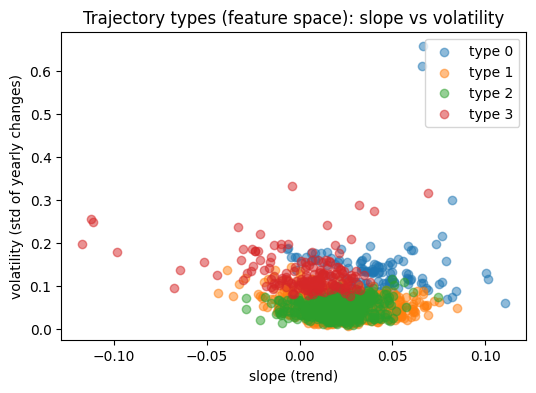

In [128]:
plt.figure(figsize=(6,4))
for t in sorted(traj_df_model["traj_type"].unique()):
    d = traj_df_model[traj_df_model["traj_type"] == t]
    plt.scatter(d["slope"], d["volatility"], alpha=0.5, label=f"type {t}")

plt.title("Trajectory types (feature space): slope vs volatility")
plt.xlabel("slope (trend)")
plt.ylabel("volatility (std of yearly changes)")
plt.legend()
plt.show()

### 4)Join trajectory types to 2018 backbone

We connect trajectory types to the 2018 backbone clusters. We restrict to counties that appear in both: the 2018 clustering sample; the panel subset used for trajectory features.


In [129]:
backbone_2018 = df_work[["county_fips_code", "cluster"]].drop_duplicates().copy()

merged_traj = backbone_2018.merge(traj_df_model[["county_fips_code", "traj_type"]], on="county_fips_code", how="inner")

print("counties with both backbone cluster and traj_type:", merged_traj.shape[0])

# Cross-tab: backbone cluster & trajectory type
pd.crosstab(merged_traj["cluster"], merged_traj["traj_type"], rownames=["backbone_cluster"], colnames=["traj_type"])

counties with both backbone cluster and traj_type: 1840


traj_type,0,1,2,3
backbone_cluster,,,,
0,32,390,347,123
1,15,121,12,1
2,69,530,158,42


Using trajectory features rather than raw time-series K-means, we identified four interpretable trajectory types based on trend and volatility. Most counties show mildly positive slopes with relatively low volatility, while a smaller group exhibits higher volatility or more extreme negative trends. This suggests that childcare burden generally increases gradually for many counties, but there are meaningful differences in stability and growth speed.

When we integrate trajectory types with the 2018 backbone clusters, we observe that trajectory patterns are not confined to a single cross-sectional group. For example, backbone cluster 2 contains a large number of counties in trajectory type 1, while cluster 0 and cluster 2 both spread across multiple trajectory types. This indicates that 2018 structural grouping and long-run trajectory patterns are related but not identical dimensions of variation.

### 5)Median burden trajectory by trajectory type




To better interpret trajectory types, we plot the median burden path over time for each type. This helps translate abstract features such as slope and volatility into intuitive time patterns. It also allows us to assess whether the trajectory types correspond to stable, steadily increasing, or more volatile affordability dynamics.

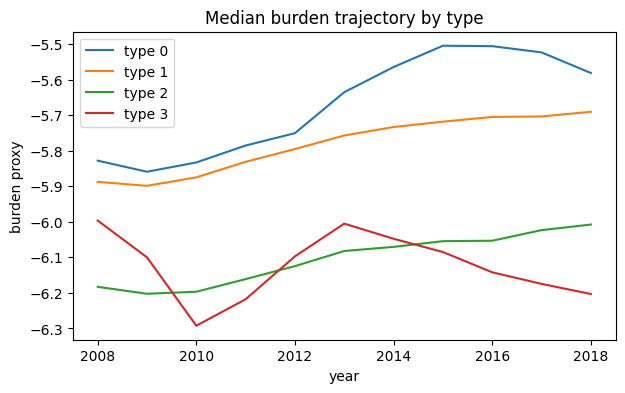

In [174]:
# Merge trajectory type back to panel data
traj_join = panel.merge(traj_df_model[["county_fips_code", "traj_type"]], on="county_fips_code", how="inner")

# Compute median trajectory per type
median_traj = (traj_join.groupby(["traj_type", "study_year"])["burden_infant"].median().unstack(0))

plt.figure(figsize=(7,4))
for t in median_traj.columns:
    plt.plot(median_traj.index, median_traj[t], label=f"type {t}")

plt.title("Median burden trajectory by type")
plt.xlabel("year")
plt.ylabel("burden proxy")
plt.legend()
plt.show()

Next, we examine how trajectory types are distributed across backbone clusters. This shows whether certain 2018 structural groups are more likely to experience specific dynamic patterns. If one cluster is dominated by a single trajectory type, it suggests stronger structural persistence. If the distribution is mixed, it suggests that cross sectional structure and dynamic evolution are related but not identical.


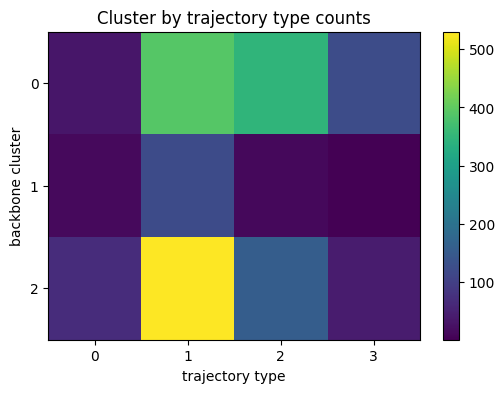

traj_type,0,1,2,3
cluster,,,,
0,32,390,347,123
1,15,121,12,1
2,69,530,158,42


In [175]:
cluster_traj = pd.crosstab(
    merged_traj["cluster"],
    merged_traj["traj_type"]
)

plt.figure(figsize=(6,4))
plt.imshow(cluster_traj, aspect="auto")
plt.xticks(range(cluster_traj.shape[1]), cluster_traj.columns)
plt.yticks(range(cluster_traj.shape[0]), cluster_traj.index)
plt.title("Cluster by trajectory type counts")
plt.colorbar()
plt.xlabel("trajectory type")
plt.ylabel("backbone cluster")
plt.show()

cluster_traj

To make the integration clearer, we convert the counts into proportions within each backbone cluster.


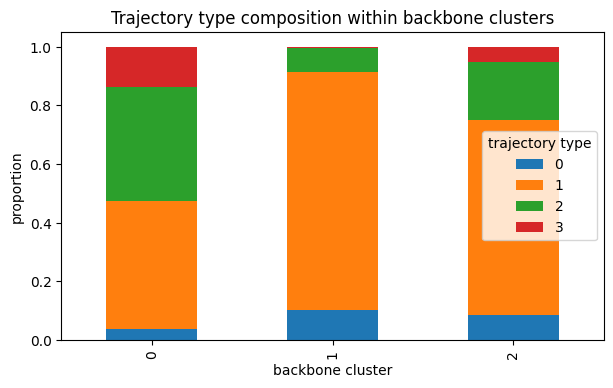

In [176]:
cluster_traj_prop = cluster_traj.div(cluster_traj.sum(axis=1), axis=0)

cluster_traj_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.title("Trajectory type composition within backbone clusters")
plt.xlabel("backbone cluster")
plt.ylabel("proportion")
plt.legend(title="trajectory type")
plt.show()

The median trajectory plot shows that the four trajectory types reflect meaningfully different burden dynamics over time. Type 0 and type 1 display steadily increasing burden proxies, indicating gradual affordability pressure growth. Type 2 remains relatively low and stable, while type 3 shows more volatility and short term fluctuation. When we integrate trajectory types with the 2018 backbone clusters, we observe partial but not perfect alignment. Cluster 1 is strongly dominated by trajectory type 1, while clusters 0 and 2 are more mixed across trajectory types.

Overall, the trajectory analysis adds a dynamic layer to the backbone clustering. It reinforces some structural patterns while also showing that cross sectional grouping does not fully determine long run burden evolution.

## 6.State Structure Analysis

In M2, we looked for evidence that counties are more similar within the same state than across states. In M3, we make this more explicit by quantifying state structure using the backbone clusters from Section 3 and the trajectory types from Section 5.

We first examine how cluster membership is distributed within each state. If state policies or state-level market conditions strongly shape childcare burden, we would expect some states to have highly concentrated cluster compositions rather than a uniform mix. We then quantify this concentration using a simple entropy-based index.

Next, we compare within-state similarity to across-state similarity by measuring how different each state's cluster distribution is from the national distribution. Then, we overlay trajectory types on top of the state structure to see whether the patterns are also state-concentrated.


### 1)Build state-level cluster distribution

In [130]:
state_cluster = pd.crosstab(df_work["state_abbreviation"], df_work["cluster"])
state_cluster.head()

cluster,0,1,2
state_abbreviation,,,
AK,0,7,0
AL,61,0,6
AR,73,0,2
AZ,4,0,11
CA,0,25,33


In [131]:
state_cluster_prop = state_cluster.div(state_cluster.sum(axis=1), axis=0)
state_cluster_prop.head()

cluster,0,1,2
state_abbreviation,,,
AK,0.000000,1.000000,0.000000
AL,0.910448,0.000000,0.089552
AR,0.973333,0.000000,0.026667
AZ,0.266667,0.000000,0.733333
CA,0.000000,0.431034,0.568966


### 2)Quantify concentration: entropy & concentration score

In [132]:
# calculate entropy
def entropy(p):
    p = p[p > 0]
    return -(p * np.log(p)).sum()

entropy_scores = state_cluster_prop.apply(lambda row: entropy(row.values), axis=1)
out = pd.DataFrame({
    "n_counties": state_cluster.sum(axis=1),
    "cluster_entropy": entropy_scores
}).sort_values("cluster_entropy")

out.head(10), out.tail(10)

(                    n_counties  cluster_entropy
 state_abbreviation                             
 AK                           7        -0.000000
 CT                           8        -0.000000
 HI                           1        -0.000000
 MA                          14        -0.000000
 MS                          82        -0.000000
 AR                          75         0.122957
 KS                         105         0.191444
 SD                          66         0.228632
 AL                          67         0.301501
 UT                          29         0.332594,
                     n_counties  cluster_entropy
 state_abbreviation                             
 CA                          58         0.683604
 ME                          16         0.702919
 MI                          83         0.703959
 PA                          67         0.707685
 NC                          99         0.794406
 WY                          23         0.805827
 MO                

In [133]:
# normalize entropy
K = state_cluster_prop.shape[1]
out["concentration_score"] = 1 - (out["cluster_entropy"] / np.log(K))

out.sort_values("concentration_score", ascending=False).head(10)

,n_counties,cluster_entropy,concentration_score
state_abbreviation,,,
AK,7,-0.000000,1.000000
CT,8,-0.000000,1.000000
HI,1,-0.000000,1.000000
MA,14,-0.000000,1.000000
MS,82,-0.000000,1.000000
AR,75,0.122957,0.888080
KS,105,0.191444,0.825740
SD,66,0.228632,0.791890
AL,67,0.301501,0.725562


Show top concentrated states and their cluster mix

In [134]:
top_states = out.sort_values("concentration_score", ascending=False).head(10).index
state_cluster_prop.loc[top_states]

cluster,0,1,2
state_abbreviation,,,
AK,0.000000,1.0,0.000000
CT,0.000000,1.0,0.000000
HI,0.000000,1.0,0.000000
MA,0.000000,1.0,0.000000
MS,1.000000,0.0,0.000000
AR,0.973333,0.0,0.026667
KS,0.952381,0.0,0.047619
SD,0.939394,0.0,0.060606
AL,0.910448,0.0,0.089552


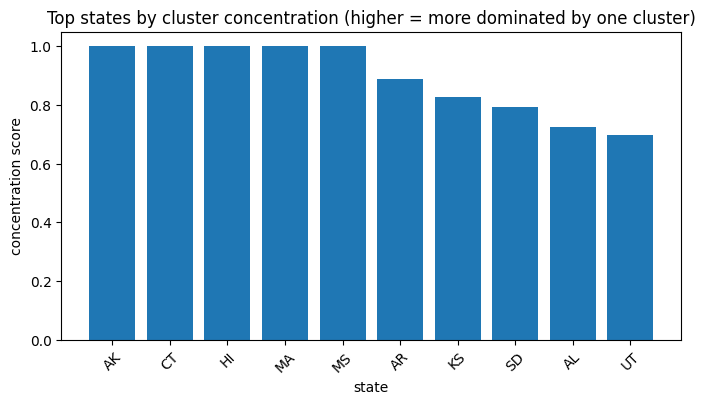

In [135]:
# top 10 concentrated states
plt.figure(figsize=(8,4))
plt.bar(top_states, out.loc[top_states, "concentration_score"])
plt.title("Top states by cluster concentration (higher = more dominated by one cluster)")
plt.xlabel("state")
plt.ylabel("concentration score")
plt.xticks(rotation=45)
plt.show()

### 3)Within-state vs across-state

To assess whether states differ meaningfully, we compare each state's cluster distribution to the overall national distribution. We use a simple L1 distance:
- 0 means the state's mix matches the national average
- larger values mean the state looks structurally different


In [136]:
national = df_work["cluster"].value_counts(normalize=True).sort_index()
national

,proportion
cluster,
0,0.477966
1,0.085593
2,0.436441


In [137]:
# align columns
state_cluster_prop_aligned = state_cluster_prop.reindex(columns=national.index, fill_value=0)

l1_dist = state_cluster_prop_aligned.apply(lambda row: np.abs(row - national).sum(), axis=1)

state_distance = pd.DataFrame({
    "n_counties": out["n_counties"],
    "concentration_score": out["concentration_score"],
    "l1_distance_to_national": l1_dist
}).sort_values("l1_distance_to_national", ascending=False)

state_distance.head(10)

,n_counties,concentration_score,l1_distance_to_national
state_abbreviation,,,
AK,7,1.000000,1.828814
HI,1,1.000000,1.828814
CT,8,1.000000,1.828814
MA,14,1.000000,1.828814
RI,5,0.544514,1.428814
NJ,21,0.395120,1.066909
MS,82,1.000000,1.044068
AR,75,0.888080,0.990734
VT,14,0.378390,0.971671


Visualize: which states deviate most from national composition

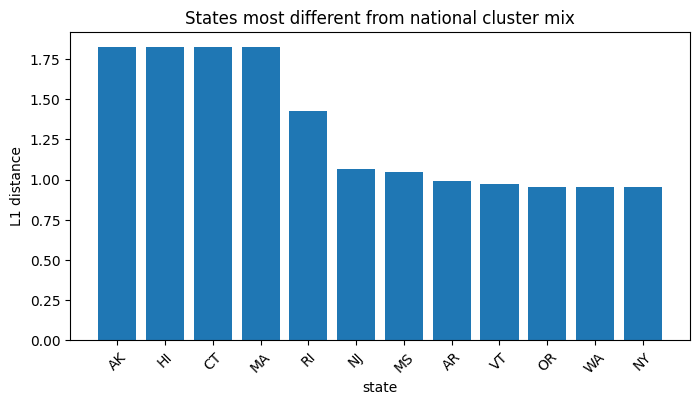

In [138]:
top_dev = state_distance.head(12).index

plt.figure(figsize=(8,4))
plt.bar(top_dev, state_distance.loc[top_dev, "l1_distance_to_national"])
plt.title("States most different from national cluster mix")
plt.xlabel("state")
plt.ylabel("L1 distance")
plt.xticks(rotation=45)
plt.show()

### 4)Join trajectory types

In Milestone 3, we test whether state-level structure also appears in the dynamic layer. We join trajectory types back to the 2018 backbone sample and compare state distributions of trajectory types.

If states show concentration in both cluster types and trajectory types, it strengthens the idea of state-level structure. If trajectory types are not state-concentrated, it suggests that temporal patterns may be driven by broader market forces rather than state-specific policies.


In [155]:
# Join trajectory types onto df_work
df_state_traj = df_work[["county_fips_code", "state_abbreviation", "cluster"]].merge(
    traj_df_model[["county_fips_code", "traj_type"]],
    on="county_fips_code",
    how="inner"
)

print("rows with cluster + traj_type:", df_state_traj.shape)
df_state_traj.head()

rows with cluster + traj_type: (1840, 4)


,county_fips_code,state_abbreviation,cluster,traj_type
0,01001,AL,0,2
1,01003,AL,0,2
2,01005,AL,0,2
3,01007,AL,0,2
4,01009,AL,2,1


In [164]:
# State & trajectory type distribution
state_traj = pd.crosstab(df_state_traj["state_abbreviation"], df_state_traj["traj_type"])
state_traj_prop = state_traj.div(state_traj.sum(axis=1), axis=0)

# Entropy / concentration for trajectory composition
K2 = state_traj_prop.shape[1]
traj_entropy = state_traj_prop.apply(lambda row: entropy(row.values), axis=1)

traj_out = pd.DataFrame({
    "n_counties": state_traj.sum(axis=1),
    "traj_entropy": traj_entropy
})
traj_out["traj_concentration_score"] = 1 - (traj_out["traj_entropy"] / np.log(K2))

traj_out.sort_values("traj_concentration_score", ascending=False).head(10)

,n_counties,traj_entropy,traj_concentration_score
state_abbreviation,,,
AZ,15,-0.000000,1.000000
CT,8,-0.000000,1.000000
HI,1,-0.000000,1.000000
DE,3,-0.000000,1.000000
MA,14,-0.000000,1.000000
CA,58,0.087100,0.937171
WA,39,0.119247,0.913982
IL,102,0.195618,0.858891
MS,82,0.342755,0.752755


In [141]:
state_joint = pd.crosstab(
    [df_state_traj["state_abbreviation"], df_state_traj["cluster"]],
    df_state_traj["traj_type"]
)

state_joint.head(10)

traj_type                   0   1   2  3
state_abbreviation cluster              
AL                 0        1  29  31  0
                   2        0   4   2  0
AZ                 0        0   4   0  0
                   2        0  11   0  0
CA                 1        1  24   0  0
                   2        0  33   0  0
CT                 1        0   8   0  0
DE                 1        0   1   0  0
                   2        0   2   0  0
HI                 1        1   0   0  0

We compare how trajectory types are distributed within backbone clusters inside each state. This allows us to assess whether state structure reinforces or diversifies dynamic burden patterns.


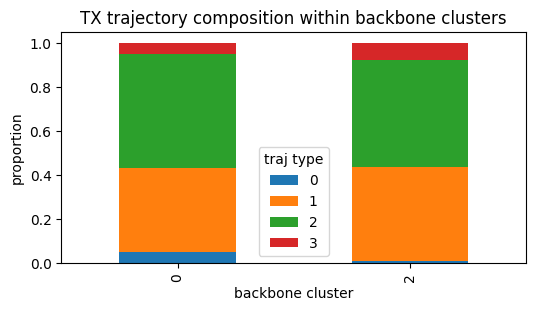

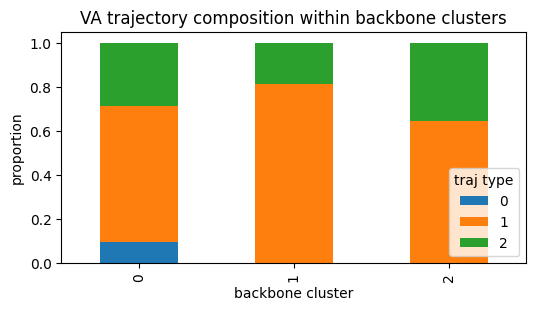

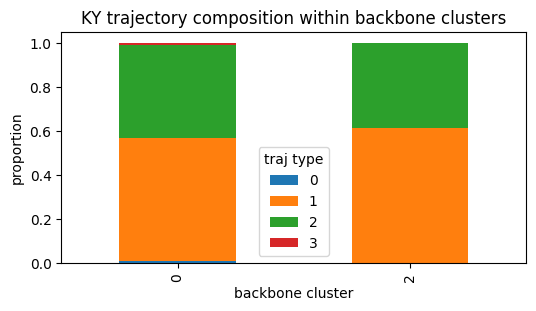

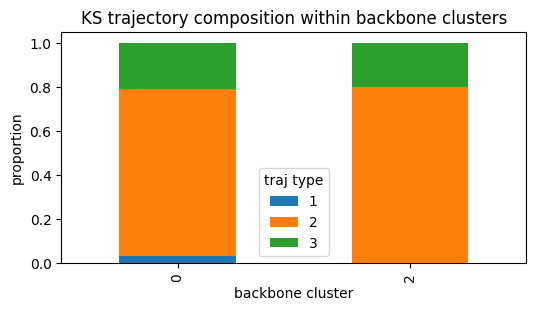

In [177]:
# Select top 4 states by county count
top_states = (df_work["state_abbreviation"].value_counts().head(4).index)

for state in top_states:
    subset = df_state_traj[df_state_traj["state_abbreviation"] == state]

    tab = pd.crosstab(subset["cluster"], subset["traj_type"])
    tab_prop = tab.div(tab.sum(axis=1), axis=0)

    tab_prop.plot(
        kind="bar",
        stacked=True,
        figsize=(6,3)
    )

    plt.title(f"{state} trajectory composition within backbone clusters")
    plt.xlabel("backbone cluster")
    plt.ylabel("proportion")
    plt.legend(title="traj type")
    plt.show()

In Texas, both cluster 0 and cluster 2 show a similar mix dominated by trajectory types 1 and 2, suggesting that dynamic burden patterns are relatively consistent within the state. In Virginia, cluster 1 is strongly dominated by a single trajectory type, while clusters 0 and 2 show slightly more variation. In Kentucky and Kansas, trajectory type 1 dominates across clusters, suggesting that counties in these states tend to follow a similar dynamic path regardless of their 2018 structural grouping. Overall, these results indicate that state context sometimes reinforces dynamic similarity within clusters, but in other cases trajectory patterns are relatively uniform across clusters.


Our state-level analysis shows that childcare burden structure is not uniformly distributed across states. Several states exhibit high cluster concentration scores, meaning that most of their counties fall into a single backbone cluster rather than being evenly mixed. Some states also show large deviations from the national cluster composition, suggesting meaningful structural differences rather than minor variation.

When we overlay trajectory types on top of backbone clusters, we observe that state structure is present but not fully deterministic. In states such as Texas and Kentucky, trajectory patterns are relatively consistent across clusters, indicating that dynamic burden paths may be shaped by broader state-level conditions. In contrast, states like Virginia show stronger alignment between specific clusters and particular trajectory types, suggesting more persistent structural dynamics. Overall, state context appears to interact with cross-sectional and dynamic patterns, but it does not fully determine long-run affordability evolution.

## 7.Conclusion

In this milestone we integrated our cross sectional clustering income adjusted residual analysis trajectory patterns and state structure into one aligned framework. The 2018 backbone clusters provide a stable structural grouping that remains largely consistent even after adding income adjusted signals. Trajectory analysis adds a dynamic layer and shows that counties within the same 2018 group can still follow different growth paths over time. State level analysis suggests that some states are more structurally concentrated while others resemble the national mix but state context does not fully determine long run patterns. Overall the different unsupervised views are related but not identical and together they provide a more complete picture of childcare burden across counties.